<a href="https://colab.research.google.com/github/P-Karthikeya512/Rock-segmentation/blob/main/Skip_Connections_modified3_UNET%2B%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split

# =========================
# CONFIG
# =========================
IMG_SIZE = (256, 256)
BATCH_SIZE = 4
EPOCHS = 50
SEED = 42

IMAGE_DIR = "/content/drive/MyDrive/dataset_rock/images"
MASK_DIR  = "/content/drive/MyDrive/dataset_rock/masks"

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

print("Images :", len(os.listdir(IMAGE_DIR)))
print("Masks  :", len(os.listdir(MASK_DIR)))

Images : 16
Masks  : 16


In [ ]:
# =========================
# PAIR IMAGES WITH MASKS
# =========================
def get_pairs(image_dir, mask_dir):
    image_paths = []
    for ext in ["jpg", "jpeg", "png", "bmp", "tif", "tiff"]:
        image_paths.extend(glob.glob(os.path.join(image_dir, f"*.{ext}")))

    image_paths = sorted(image_paths)

    mask_map = {}
    for ext in ["jpg", "jpeg", "png", "bmp", "tif", "tiff"]:
        for p in glob.glob(os.path.join(mask_dir, f"*.{ext}")):
            stem = os.path.splitext(os.path.basename(p))[0]
            mask_map[stem] = p

    pairs = []
    for img_path in image_paths:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        if stem in mask_map:
            pairs.append((img_path, mask_map[stem]))
        else:
            print(f"Warning: no mask found for {img_path}")

    return pairs

pairs = get_pairs(IMAGE_DIR, MASK_DIR)
print("Total paired samples:", len(pairs))

# =========================
# LOAD IMAGE + MASK
# =========================
def load_image_mask(img_path, mask_path):
    img = cv2.imread(img_path.decode(), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32) / 255.0

    mask = cv2.imread(mask_path.decode(), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise ValueError(f"Could not read mask: {mask_path}")
    mask = cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    mask = (mask > 127).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

def tf_load_image_mask(img_path, mask_path):
    img, mask = tf.numpy_function(
        func=load_image_mask,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )
    img.set_shape([IMG_SIZE[0], IMG_SIZE[1], 3])
    mask.set_shape([IMG_SIZE[0], IMG_SIZE[1], 1])
    return img, mask

# =========================
# DATASET
# =========================
train_pairs, val_pairs = train_test_split(
    pairs, test_size=0.2, random_state=SEED
)

def duplicate_mask(image, mask):
    return image, (mask, mask, mask, mask)

def make_dataset(pairs, training=True, duplicate=False):
    img_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))

    if training:
        ds = ds.shuffle(buffer_size=len(pairs), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(tf_load_image_mask, num_parallel_calls=AUTOTUNE)

    if duplicate:
        ds = ds.map(duplicate_mask, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds_multi = make_dataset(train_pairs, training=True, duplicate=True)
val_ds_multi   = make_dataset(val_pairs, training=False, duplicate=True)

train_ds_single = make_dataset(train_pairs, training=True, duplicate=False)
val_ds_single   = make_dataset(val_pairs, training=False, duplicate=False)

print("Train samples:", len(train_pairs))
print("Val samples:", len(val_pairs))

Total paired samples: 16
Train samples: 12
Val samples: 4


In [ ]:
# =========================
# LOSS + METRICS
# =========================
bce_loss_fn = tf.keras.losses.BinaryCrossentropy()

def dice_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def combined_bce_dice_loss(y_true, y_pred):
    bce = bce_loss_fn(y_true, y_pred)
    dloss = dice_loss(y_true, y_pred)
    return 0.5 * bce + dloss

def iou_coef(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.ReLU()(x)
    return x

class LearnableKernelLayer(layers.Layer):
    """
    Learnable depthwise kernel bank initialized with:
    - Sobel X
    - Sobel Y
    - Laplacian

    Input:  [B, H, W, C]
    Output: [B, H, W, 3C]
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        c = int(input_shape[-1])

        sobel_x = np.array([
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]
        ], dtype=np.float32)

        sobel_y = np.array([
            [-1, -2, -1],
            [ 0,  0,  0],
            [ 1,  2,  1]
        ], dtype=np.float32)

        laplacian = np.array([
            [ 0,  1,  0],
            [ 1, -4,  1],
            [ 0,  1,  0]
        ], dtype=np.float32)

        # depthwise kernel shape: [3, 3, in_channels, channel_multiplier]
        init_kernel = np.zeros((3, 3, c, 3), dtype=np.float32)

        for ch in range(c):
            init_kernel[:, :, ch, 0] = sobel_x
            init_kernel[:, :, ch, 1] = sobel_y
            init_kernel[:, :, ch, 2] = laplacian

        self.kernel = self.add_weight(
            name="kernel",
            shape=(3, 3, c, 3),
            initializer=tf.keras.initializers.Constant(init_kernel),
            trainable=True
        )

    def call(self, x):
        return tf.nn.depthwise_conv2d(
            x,
            self.kernel,
            strides=[1, 1, 1, 1],
            padding="SAME"
        )

def merge_with_learnable_kernels(inputs_list, filters, prefix):
    """
    For each incoming tensor:
      original feature
      + learnable-kernel response of that feature
    Then concatenate all and compress with 1x1 conv.
    """
    original_feats = inputs_list
    learned_feats = []

    for idx, feat in enumerate(original_feats):
        lk = LearnableKernelLayer(name=f"{prefix}_learnable_{idx}")(feat)
        learned_feats.append(lk)

    x = layers.Concatenate(name=f"{prefix}_concat")(original_feats + learned_feats)

    # channel compression to control memory
    x = layers.Conv2D(
        filters,
        1,
        padding="same",
        kernel_initializer="he_normal",
        name=f"{prefix}_compress"
    )(x)
    x = layers.ReLU(name=f"{prefix}_compress_relu")(x)
    return x

# =========================
# BUILD UNET++ WITH LEARNABLE-KERNEL IMPROVEMENT
# =========================
def build_unet_plus_plus_fixed(input_shape=(256, 256, 3)):
    """
    Modified UNet++:
    For each X(i,j), use:
      - normal UNet++ inputs
      - learnable-kernel responses of each input
    Then apply the main conv block.
    """
    filters = [32, 64, 128, 256, 512]
    depth = len(filters) - 1

    inputs = layers.Input(shape=input_shape)
    X = {}

    # Encoder backbone: X[i,0]
    x = inputs
    for i in range(depth + 1):
        X[(i, 0)] = conv_block(x, filters[i])
        if i < depth:
            x = layers.MaxPooling2D((2, 2))(X[(i, 0)])

    # Nested decoder / skip pathways
    for j in range(1, depth + 1):
        for i in range(0, depth - j + 1):
            up = layers.Conv2DTranspose(
                filters[i],
                kernel_size=2,
                strides=2,
                padding="same",
                name=f"up_{i}_{j}"
            )(X[(i + 1, j - 1)])

            base_feats = [X[(i, k)] for k in range(j)] + [up]
            merged = merge_with_learnable_kernels(
                base_feats,
                filters[i],
                prefix=f"merge_{i}_{j}"
            )
            X[(i, j)] = conv_block(merged, filters[i])

    # Deep supervision heads
    side_outputs = [
        layers.Conv2D(1, 1, activation="sigmoid", name=f"side_{j}")(X[(0, j)])
        for j in range(1, depth + 1)
    ]

    train_model = Model(inputs, side_outputs, name="UNetPlusPlus_LearnableKernel_Train")
    avg_output = layers.Average(name="avg_output")(side_outputs)
    infer_model = Model(inputs, avg_output, name="UNetPlusPlus_LearnableKernel_Infer")

    return train_model, infer_model

train_model, infer_model = build_unet_plus_plus_fixed()

train_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=[combined_bce_dice_loss for _ in range(4)],
    loss_weights=[0.25, 0.25, 0.25, 0.25],
    metrics=[
        ["accuracy", dice_coef, iou_coef],
        ["accuracy", dice_coef, iou_coef],
        ["accuracy", dice_coef, iou_coef],
        ["accuracy", dice_coef, iou_coef],
    ]
)

infer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=combined_bce_dice_loss,
    metrics=["accuracy", dice_coef, iou_coef]
)

train_model.summary()
infer_model.summary()

Model: "UNetPlusPlus_LearnableKernel_Train"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ re_lu_4[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ re_lu_5[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 8,813,092 (33.62 MB)

 Trainable params: 8,813,092 (33.62 MB)

 Non-trainable params: 0 (0.00 B)

Model: "UNetPlusPlus_LearnableKernel_Infer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ conv2d_3[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ re_lu_4[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ re_lu_5[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[

 Total params: 8,813,092 (33.62 MB)

 Trainable params: 8,813,092 (33.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - loss: 0.7795 - side_1_accuracy: 0.4536 - side_1_dice_coef: 0.5544 - side_1_iou_coef: 0.3842 - side_1_loss: 0.8056 - side_2_accuracy: 0.5147 - side_2_dice_coef: 0.5887 - side_2_iou_coef: 0.4178 - side_2_loss: 0.7648 - side_3_accuracy: 0.6198 - side_3_dice_coef: 0.7035 - side_3_iou_coef: 0.5431 - side_3_loss: 0.6977 - side_4_accuracy: 0.5398 - side_4_dice_coef: 0.6173 - side_4_iou_coef: 0.4517 - side_4_loss: 0.8499
val_avg_loss=0.7190  val_avg_accuracy=0.5626  val_avg_dice_coef=0.6430  val_avg_iou_coef=0.4738

Epoch 1: val_avg_dice_coef improved from None to 0.64297, saving model to best_unetpp_fixedconv.keras

Epoch 1: finished saving model to best_unetpp_fixedconv.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 105s 15s/step - loss: 0.7533 - side_1_accuracy: 0.5117 - side_1_dice_coef: 0.5701 - side_1_iou_coef: 0.3993 - side_1_loss: 0.7814 - side_2_accuracy: 0.5350 - side_2_dice_coef: 0.6027 - side_2_iou_coef: 0.4319 - side_2_loss: 0.7444 - side_3_accu

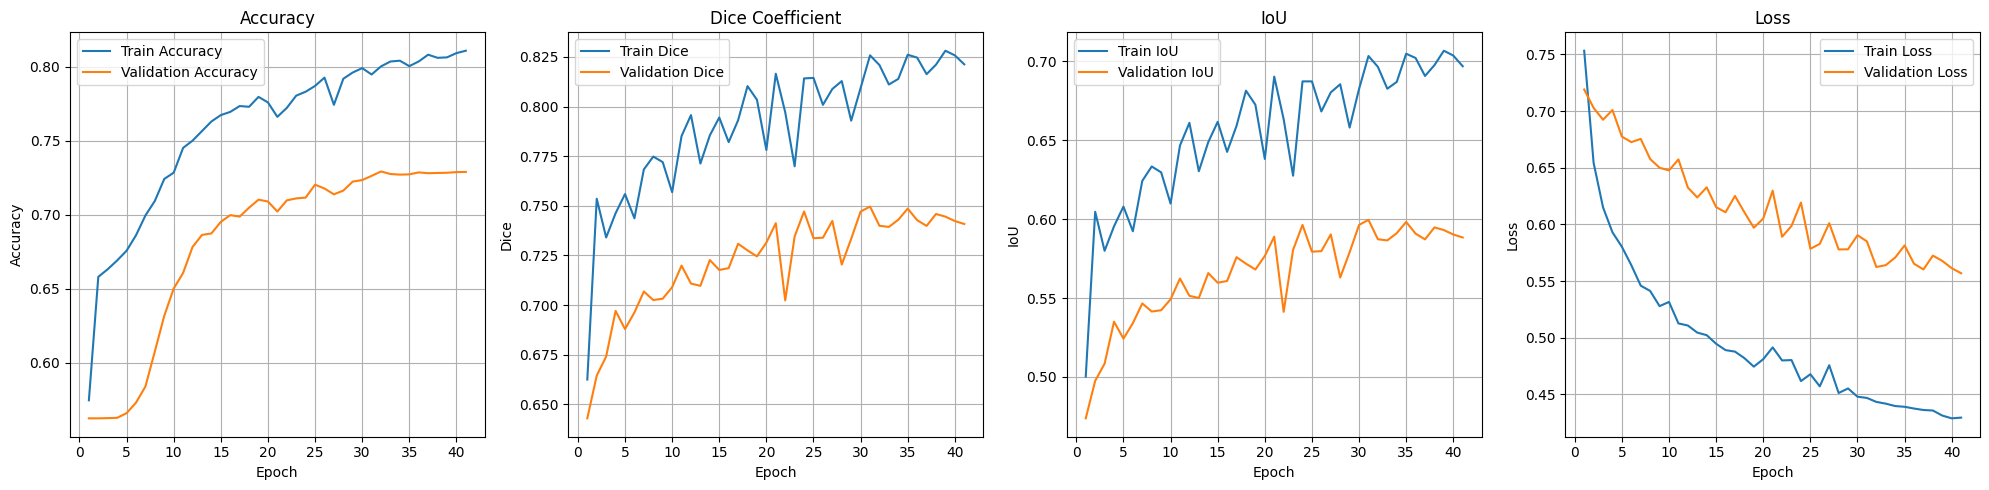

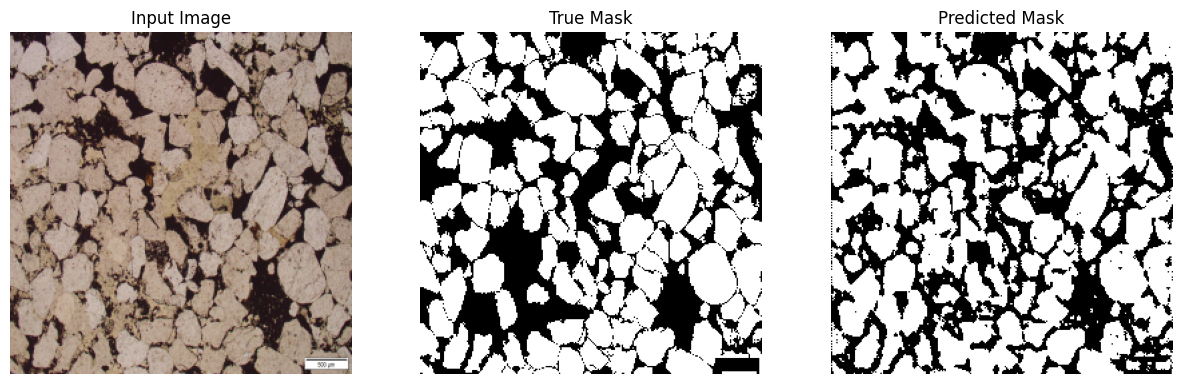

In [ ]:
# =========================
# CALLBACK: EVALUATE AVERAGED OUTPUT MODEL
# =========================
class EvaluateAveragedModel(tf.keras.callbacks.Callback):
    def __init__(self, averaged_model, val_ds):
        super().__init__()
        self.averaged_model = averaged_model
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}

        results = self.averaged_model.evaluate(
            self.val_ds,
            verbose=0,
            return_dict=True
        )

        logs["val_avg_loss"] = float(results["loss"])
        logs["val_avg_accuracy"] = float(results["accuracy"])
        logs["val_avg_dice_coef"] = float(results["dice_coef"])
        logs["val_avg_iou_coef"] = float(results["iou_coef"])

        print(
            f"\nval_avg_loss={logs['val_avg_loss']:.4f}  "
            f"val_avg_accuracy={logs['val_avg_accuracy']:.4f}  "
            f"val_avg_dice_coef={logs['val_avg_dice_coef']:.4f}  "
            f"val_avg_iou_coef={logs['val_avg_iou_coef']:.4f}"
        )

paper_eval_cb = EvaluateAveragedModel(infer_model, val_ds_single)

# =========================
# CALLBACKS
# =========================
callbacks = [
    paper_eval_cb,
    tf.keras.callbacks.ModelCheckpoint(
        "best_unetpp_fixedconv.keras",
        monitor="val_avg_dice_coef",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_avg_dice_coef",
        mode="max",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_avg_dice_coef",
        mode="max",
        factor=0.5,
        patience=4,
        verbose=1
    )
]

# =========================
# TRAIN
# =========================
history = train_model.fit(
    train_ds_multi,
    validation_data=val_ds_multi,
    epochs=EPOCHS,
    callbacks=callbacks
)

# =========================
# PLOTS
# =========================
def plot_training_curves(history):
    hist = history.history
    epochs_range = range(1, len(hist["loss"]) + 1)
    plt.figure(figsize=(20, 5))

    plt.subplot(1, 4, 1)
    if "side_4_accuracy" in hist:
        plt.plot(epochs_range, hist["side_4_accuracy"], label="Train Accuracy")
    if "val_avg_accuracy" in hist:
        plt.plot(epochs_range, hist["val_avg_accuracy"], label="Validation Accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 4, 2)
    if "side_4_dice_coef" in hist:
        plt.plot(epochs_range, hist["side_4_dice_coef"], label="Train Dice")
    if "val_avg_dice_coef" in hist:
        plt.plot(epochs_range, hist["val_avg_dice_coef"], label="Validation Dice")
    plt.title("Dice Coefficient")
    plt.xlabel("Epoch")
    plt.ylabel("Dice")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 4, 3)
    if "side_4_iou_coef" in hist:
        plt.plot(epochs_range, hist["side_4_iou_coef"], label="Train IoU")
    if "val_avg_iou_coef" in hist:
        plt.plot(epochs_range, hist["val_avg_iou_coef"], label="Validation IoU")
    plt.title("IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 4, 4)
    plt.plot(epochs_range, hist["loss"], label="Train Loss")
    if "val_avg_loss" in hist:
        plt.plot(epochs_range, hist["val_avg_loss"], label="Validation Loss")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_curves(history)

# =========================
# PREDICTION + VISUALIZATION
# =========================
def show_prediction(model, pair):
    img_path, mask_path = pair
    img, mask = load_image_mask(img_path.encode(), mask_path.encode())

    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    pred_mask = (pred > 0.5).astype(np.uint8)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask.squeeze(), cmap="gray")
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask.squeeze(), cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()

show_prediction(infer_model, val_pairs[0])